In [1]:
import sys
import json
import pathlib

import pandas as pd
import matplotlib.pyplot as plt

# Locate the repository root (the directory that contains simulation_engine) so the
# notebook runs regardless of the directory Jupyter was launched from.
repository_path = pathlib.Path.cwd()
while not (repository_path / "simulation_engine").is_dir() and repository_path != repository_path.parent:
    repository_path = repository_path.parent
machine_learning_path = repository_path / "notebooks" / "machine_learning"
for path_entry in (str(repository_path), str(machine_learning_path)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)

import rl_helpers.rl_plots as rl_plots

data_rl_path = repository_path / "data" / "rl"

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 3 - Training and convergence

This notebook trains the agents by self-play and inspects convergence. Two update rules are
compared on identical schedules: **Q-learning** (off-policy) and **SARSA** (on-policy).

Training is expensive, so the full experiment matrix - player counts {6, 7, 8}, both rules, and the
three ablations (mission-only, participant-only, joint) - is precomputed and saved under `data/rl/`.
Set `RETRAIN = True` to regenerate everything from scratch.

## The learning rule

Each agent keeps a sparse table $Q(s, a)$. After a transition $(s, a, r, s')$ it updates

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\,r + \gamma\, B - Q(s,a)\,\big],$$

where the bootstrap term $B$ distinguishes the two rules:

- **Q-learning** (off-policy): $B = \max_{a'} Q(s', a')$ - the value of the *best* next action.
- **SARSA** (on-policy): $B = Q(s', a')$ for the action $a'$ the behaviour policy *actually took* next.

Terminal transitions drop $B$ entirely ($B = 0$). The learning rate $\alpha$ and the exploration
rate $\epsilon$ decay linearly over training; the discount is $\gamma = 0.95$. Exploration draws
from a private RNG so the seeded game dynamics stay reproducible.

In [2]:
RETRAIN = False

if RETRAIN:
    import rl_helpers.experiment as experiment
    experiment.train_and_evaluate_all()

manifest = json.loads((data_rl_path / 'manifest.json').read_text())
print('episodes per agent:', manifest['n_episodes'])
print('evaluation games:', manifest['eval_games'])
print('schedules:', manifest['schedules'])
print('reward config:', manifest['reward_config'])

episodes per agent: 30000
evaluation games: 4000
schedules: {'alpha_start': 0.5, 'alpha_end': 0.05, 'gamma': 0.95, 'epsilon_start': 1.0, 'epsilon_end': 0.02, 'epsilon_decay_episodes': 21000}
reward config: {'win_reward': 1.0, 'loss_reward': -1.0, 'boat_part_reward': 0.1, 'step_penalty': 0.002, 'use_shaping': True}


## Convergence for the joint agents

We plot the three diagnostics for the joint experiment at player count 7: the training-block win
rate, the mean absolute TD error (which should fall as the value estimates settle), and the number
of distinct states in the Q-table (which should plateau well below the 4608-key cap). The dashed
line is the rule-based baseline win rate.

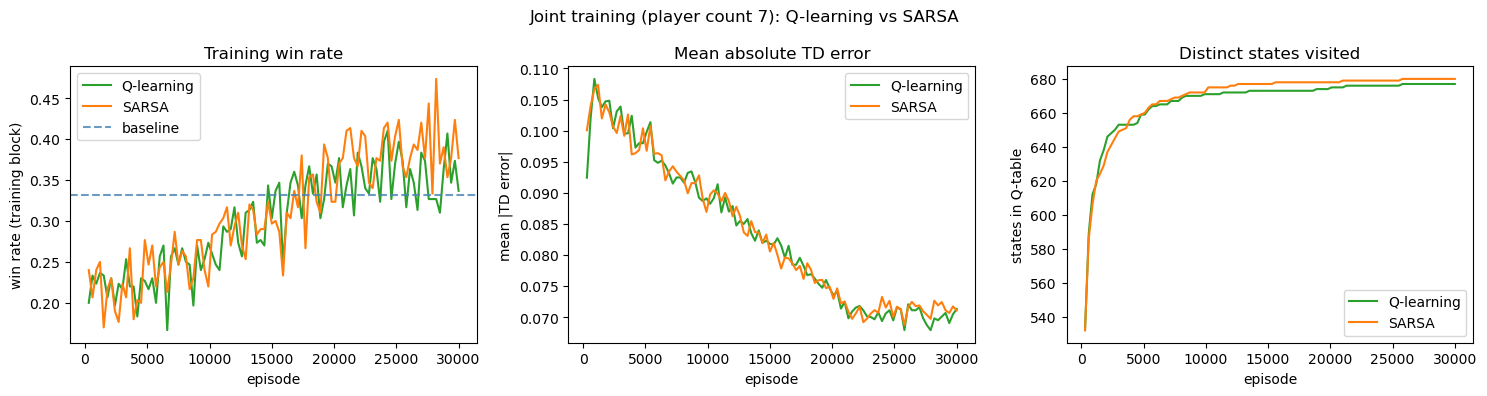

In [3]:
def load_curves(ablation, update_rule, player_count):
    return json.loads((data_rl_path / f'curves_{ablation}_{update_rule}_pc{player_count}.json').read_text())

def load_eval(ablation, update_rule, player_count):
    return json.loads((data_rl_path / f'eval_{ablation}_{update_rule}_pc{player_count}.json').read_text())

curves_by_rule = {rule: load_curves('joint', rule, 7) for rule in ('q_learning', 'sarsa')}
baseline_win_rate = load_eval('joint', 'q_learning', 7)['baseline_win_rate']
figure = rl_plots.plot_training_curves(
    curves_by_rule, baseline_win_rate = baseline_win_rate,
    title = 'Joint training (player count 7): Q-learning vs SARSA',
)
plt.show()

## State coverage across the matrix

The final Q-table sizes confirm the abstraction stays compact: the mission table fills a few
hundred to roughly a thousand of its 4608 keys, the participant table only a few dozen of 144.

In [4]:
rows = []
for player_count in manifest['player_counts']:
    for rule in manifest['update_rules']:
        curves = load_curves('joint', rule, player_count)
        rows.append({
            'player_count': player_count,
            'update_rule': rule,
            'final_win_rate_block': round(curves['win_rate_curve'][-1], 3),
            'final_td_error': round(curves['td_error_curve'][-1], 4),
            'mission_states': curves['mission_states_curve'][-1],
            'participant_states': curves['participant_states_curve'][-1],
        })
pd.DataFrame(rows)

,player_count,update_rule,final_win_rate_block,final_td_error,mission_states,participant_states
0,6,q_learning,0.330,0.0857,481,48
1,6,sarsa,0.333,0.0842,480,48
2,7,q_learning,0.337,0.0713,677,48
3,7,sarsa,0.377,0.0711,680,48
4,8,q_learning,0.443,0.0641,872,48
5,8,sarsa,0.437,0.0641,871,48


The TD error settles to a small floor and the visited-state counts plateau, so the tables are well
filled rather than starved. Notebook 4 asks the decisive question: does any of this beat the
hand-written baseline?